# Stage 1 — Mass distribution recovery without PSF convolution and noise

This first direct mass-forward-modeling test uses

$$V_c^2(R)=V_{\rm disk}^2+V_{\rm Hernquist}^2+V_{\rm NFW}^2.
$$

There is no Courteau model, lensing, PSF convolution, or noise. Geometry, line emission, and gas dispersion are fixed. Which mass parameters are free is controlled by `mock_stage1.toml`; the forward model itself always receives a complete numerical parameter set.

In [1]:
import sys
import tomllib
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
from scipy.optimize import least_squares

%matplotlib inline

cwd = Path.cwd().resolve()
if (cwd / 'examples' / 'forward_mass').exists():
    REPO_ROOT = cwd
    EXAMPLE_DIR = cwd / 'examples' / 'forward_mass'
elif cwd.name == 'forward_mass':
    EXAMPLE_DIR = cwd
    REPO_ROOT = cwd.parents[1]
else:
    raise FileNotFoundError('Run from the glint repository root or examples/forward_mass.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from glint.cosmology import critical_density, kpc_per_arcsec
from glint.forward import forward_model_3D_mass_intrinsic, mass_rotation_curve
from glint.mass_model import r200_kpc_from_m200

## Configuration

Human-editable mock values, bounds, initial values, and the free-parameter list live in `mock_stage1.toml`. Cosmological quantities are evaluated once here, outside the optimizer.

In [2]:
with (EXAMPLE_DIR / 'mock_stage1.toml').open('rb') as handle:
    CONFIG = tomllib.load(handle)

SOURCE_REDSHIFT = float(CONFIG['target']['redshift'])
KPC_PER_ARCSEC = kpc_per_arcsec(SOURCE_REDSHIFT)
RHO_CRITICAL_MSUN_KPC3 = critical_density(SOURCE_REDSHIFT)
HALO_CONCENTRATION_200 = float(CONFIG['mass_model']['halo_concentration_200'])

ALL_PARAMETER_NAMES = (
    'log10_m_baryon',
    'bulge_to_total',
    'disk_scale_radius_kpc',
    'bulge_effective_radius_kpc',
    'log10_m200',
)
FREE_PARAMETER_NAMES = tuple(CONFIG['fit']['free_parameters'])
unknown = set(FREE_PARAMETER_NAMES) - set(ALL_PARAMETER_NAMES)
if unknown:
    raise ValueError(f'Unknown free parameters: {sorted(unknown)}')

bounds_config = CONFIG['fit']['bounds']
LOWER_BOUNDS = np.array([bounds_config[name]['lower'] for name in FREE_PARAMETER_NAMES])
UPPER_BOUNDS = np.array([bounds_config[name]['upper'] for name in FREE_PARAMETER_NAMES])
INITIAL_GUESS = np.array([bounds_config[name]['initial'] for name in FREE_PARAMETER_NAMES])

print(f'z = {SOURCE_REDSHIFT:.3f}')
print(f'kpc/arcsec = {KPC_PER_ARCSEC:.4f}')
print(f'rho_critical = {RHO_CRITICAL_MSUN_KPC3:.4e} Msun/kpc^3')
print(f'fixed c200 = {HALO_CONCENTRATION_200:.1f}')
print('free parameters:', FREE_PARAMETER_NAMES)

z = 6.024
kpc/arcsec = 5.6972
rho_critical = 1.4262e+04 Msun/kpc^3
fixed c200 = 3.0
free parameters: ('log10_m_baryon', 'bulge_to_total', 'disk_scale_radius_kpc', 'bulge_effective_radius_kpc', 'log10_m200')


## Physical cases and numerical grid

Six combinations of bulge fraction and effective radius are generated from the TOML lists.

In [3]:
mass_cfg = CONFIG['mass_model']
cube_cfg = CONFIG['cube']
source_cfg = CONFIG['source']

def case_name(bulge_to_total, bulge_effective_radius_kpc):
    return f'bt{round(100 * bulge_to_total):02d}_re{round(10 * bulge_effective_radius_kpc):02d}'

def make_cases():
    cases = []
    for bt, re_kpc in product(
        mass_cfg['bulge_to_total_values'],
        mass_cfg['bulge_effective_radii_kpc'],
    ):
        cases.append({
            'name': case_name(bt, re_kpc),
            'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
            'bulge_to_total': float(bt),
            'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
            'bulge_effective_radius_kpc': float(re_kpc),
            'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
        })
    if mass_cfg.get('include_no_bulge_case', False):
        cases.append({
            'name': 'bt00',
            'log10_m_baryon': np.log10(mass_cfg['total_baryonic_mass_msun']),
            'bulge_to_total': 0.0,
            'disk_scale_radius_kpc': float(mass_cfg['disk_scale_radius_kpc']),
            # Positive placeholder required by the common forward-model signature; physically irrelevant at zero bulge mass.
            'bulge_effective_radius_kpc': float(mass_cfg['no_bulge_placeholder_radius_kpc']),
            'log10_m200': np.log10(mass_cfg['halo_mass_200_msun']),
        })
    return tuple(cases)

CASES = make_cases()
axis = (np.arange(cube_cfg['grid_size']) - (cube_cfg['grid_size'] - 1) / 2) * cube_cfg['pixel_size_arcsec']
XX_ARCSEC, YY_ARCSEC = np.meshgrid(axis, axis)
RADIUS_ARCSEC = np.linspace(0.0, cube_cfg['radius_max_arcsec'], cube_cfg['radial_samples'])
RADIUS_KPC = RADIUS_ARCSEC * KPC_PER_ARCSEC
VELOCITY_CHANNELS_KMS = np.arange(
    cube_cfg['velocity_min_kms'],
    cube_cfg['velocity_max_kms'] + 0.5 * cube_cfg['channel_width_kms'],
    cube_cfg['channel_width_kms'],
)
SPATIAL_MASK = np.hypot(XX_ARCSEC, YY_ARCSEC) <= cube_cfg['radius_max_arcsec']
FIT_MASK = np.broadcast_to(SPATIAL_MASK, (VELOCITY_CHANNELS_KMS.size, *SPATIAL_MASK.shape))

Table(
    rows=[(case['name'], *(case[name] for name in ALL_PARAMETER_NAMES)) for case in CASES],
    names=('case', *ALL_PARAMETER_NAMES),
)

case,log10_m_baryon,bulge_to_total,disk_scale_radius_kpc,bulge_effective_radius_kpc,log10_m200
str9,float64,float64,float64,float64,float64
bt10_re03,11.0,0.1,1.0,0.3,11.477121254719663
bt10_re06,11.0,0.1,1.0,0.6,11.477121254719663
bt25_re03,11.0,0.25,1.0,0.3,11.477121254719663
bt25_re06,11.0,0.25,1.0,0.6,11.477121254719663
bt50_re03,11.0,0.5,1.0,0.3,11.477121254719663
bt50_re06,11.0,0.5,1.0,0.6,11.477121254719663
bt00,11.0,0.0,1.0,0.3,11.477121254719663


## Thin experiment layer

These helpers only translate between optimizer vectors and the complete physical keyword set. The reusable rotation-curve and cube calculations remain in `glint.forward`. Fixed/free choices never add branches inside the numerical forward model.

In [4]:
def free_vector(parameters):
    return np.array([parameters[name] for name in FREE_PARAMETER_NAMES], dtype=float)

def complete_parameters(theta_free, fixed_case):
    parameters = {name: float(fixed_case[name]) for name in ALL_PARAMETER_NAMES}
    parameters.update(zip(FREE_PARAMETER_NAMES, np.asarray(theta_free, dtype=float), strict=True))
    return parameters

def physical_keywords(parameters):
    baryonic_mass = 10.0 ** parameters['log10_m_baryon']
    bulge_mass = parameters['bulge_to_total'] * baryonic_mass
    halo_mass = 10.0 ** parameters['log10_m200']
    return {
        'disk_mass_msun': baryonic_mass - bulge_mass,
        'disk_scale_radius_kpc': parameters['disk_scale_radius_kpc'],
        'bulge_mass_msun': bulge_mass,
        'bulge_effective_radius_kpc': parameters['bulge_effective_radius_kpc'],
        'halo_mass_200_msun': halo_mass,
        'halo_radius_200_kpc': r200_kpc_from_m200(halo_mass, RHO_CRITICAL_MSUN_KPC3),
        'halo_concentration_200': HALO_CONCENTRATION_200,
    }

def rotation_curve(parameters):
    return mass_rotation_curve(radius_kpc=RADIUS_KPC, **physical_keywords(parameters))

def intrinsic_cube(parameters):
    surface_brightness = np.exp(-RADIUS_ARCSEC / source_cfg['surface_brightness_scale_arcsec'])
    dispersion = np.full_like(RADIUS_ARCSEC, source_cfg['velocity_dispersion_kms'])
    return forward_model_3D_mass_intrinsic(
        xx_arcsec=XX_ARCSEC,
        yy_arcsec=YY_ARCSEC,
        radius_arcsec=RADIUS_ARCSEC,
        kpc_per_arcsec=KPC_PER_ARCSEC,
        velocity_channels_kms=VELOCITY_CHANNELS_KMS,
        surface_brightness_profile=surface_brightness,
        velocity_dispersion_profile_kms=dispersion,
        inclination_deg=source_cfg['inclination_deg'],
        position_angle_deg=source_cfg['position_angle_deg'],
        systemic_velocity_kms=source_cfg['systemic_velocity_kms'],
        spectral_resolution_sigma_kms=cube_cfg['spectral_resolution_sigma_kms'],
        radius_max_arcsec=cube_cfg['radius_max_arcsec'],
        **physical_keywords(parameters),
    )

## Recover all mocks

Every fit starts from the TOML initial values. Parameters omitted from `fit.free_parameters` remain fixed to that case's truth value.

In [5]:
def recover_case(case):
    truth_free = free_vector(case)
    data_cube = intrinsic_cube(case)
    scale = float(np.max(data_cube))

    def residual(theta_free):
        model = intrinsic_cube(complete_parameters(theta_free, case))
        return ((model - data_cube) / scale)[FIT_MASK]

    fit = least_squares(
        residual, INITIAL_GUESS, bounds=(LOWER_BOUNDS, UPPER_BOUNDS),
        x_scale='jac', ftol=1e-11, xtol=1e-11, gtol=1e-11, max_nfev=2000,
    )
    best_parameters = complete_parameters(fit.x, case)
    best_cube = intrinsic_cube(best_parameters)
    singular_values = np.linalg.svd(fit.jac, compute_uv=False)
    return {
        'truth_free': truth_free, 'best_free': fit.x,
        'best_parameters': best_parameters,
        'data_cube': data_cube, 'best_cube': best_cube,
        'max_abs_cube_residual': float(np.max(np.abs(best_cube - data_cube))),
        'success': fit.success, 'nfev': fit.nfev,
        'jacobian_singular_values': singular_values,
    }

RESULTS = {}
for case in CASES:
    result = recover_case(case)
    RESULTS[case['name']] = result
    print(case['name'], 'success=', result['success'], 'nfev=', result['nfev'],
          'max |cube residual|=', f"{result['max_abs_cube_residual']:.3e}")

bt10_re03 success= True nfev= 24 max |cube residual|= 3.353e-08
bt10_re06 success= True nfev= 22 max |cube residual|= 2.235e-08
bt25_re03 success= True nfev= 27 max |cube residual|= 1.192e-07
bt25_re06 success= True nfev= 22 max |cube residual|= 4.470e-08
bt50_re03 success= True nfev= 47 max |cube residual|= 3.353e-08
bt50_re06 success= True nfev= 29 max |cube residual|= 3.353e-08
bt00 success= True nfev= 48 max |cube residual|= 1.937e-07


In [6]:
rows = []
for case in CASES:
    result = RESULTS[case['name']]
    row = [case['name']]
    for truth, best in zip(result['truth_free'], result['best_free'], strict=True):
        row.extend((truth, best, best - truth))
    row.extend((result['max_abs_cube_residual'], result['nfev']))
    rows.append(row)
names = ['case']
for name in FREE_PARAMETER_NAMES:
    names.extend((f'{name}_truth', f'{name}_best', f'{name}_delta'))
names.extend(('max_cube_residual', 'nfev'))
recovery_table = Table(rows=rows, names=names)
for name in recovery_table.colnames[1:-1]:
    recovery_table[name].format = '.6g'
recovery_table

case,log10_m_baryon_truth,log10_m_baryon_best,log10_m_baryon_delta,bulge_to_total_truth,bulge_to_total_best,bulge_to_total_delta,disk_scale_radius_kpc_truth,disk_scale_radius_kpc_best,disk_scale_radius_kpc_delta,bulge_effective_radius_kpc_truth,bulge_effective_radius_kpc_best,bulge_effective_radius_kpc_delta,log10_m200_truth,log10_m200_best,log10_m200_delta,max_cube_residual,nfev
str9,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
bt10_re03,11,11,2.20795e-08,0.1,0.1,9.22691e-09,1,1,3.05071e-08,0.3,0.3,4.83715e-08,11.4771,11.4771,-2.12064e-07,3.35276e-08,24
bt10_re06,11,11,3.73061e-09,0.1,0.1,1.3933e-08,1,1,5.14938e-09,0.6,0.6,8.59947e-08,11.4771,11.4771,7.47013e-10,2.23517e-08,22
bt25_re03,11,11,-8.48032e-08,0.25,0.25,-3.2113e-09,1,1,-1.3327e-07,0.3,0.3,-6.15982e-08,11.4771,11.4771,8.50812e-07,1.19209e-07,27
bt25_re06,11,11,-2.86602e-08,0.25,0.25,-2.06319e-08,1,1,-4.51077e-08,0.6,0.6,-5.85149e-08,11.4771,11.4771,2.29778e-07,4.47035e-08,22
bt50_re03,11,11,5.16265e-08,0.5,0.5,-9.64187e-09,1,1,1.38684e-07,0.3,0.3,3.89391e-08,11.4771,11.4771,-4.33683e-07,3.35276e-08,47
bt50_re06,11,11,7.77359e-08,0.5,0.5,2.85343e-08,1,1,1.58651e-07,0.6,0.6,1.35723e-07,11.4771,11.4771,-5.8502e-07,3.35276e-08,29
bt00,11,11,1.80898e-07,0,9.57584e-08,9.57584e-08,1,1,2.01207e-07,0.3,0.999991,0.699991,11.4771,11.4771,-1.67752e-06,1.93715e-07,48


## Rotation-curve recovery

Solid black is the truth, dashed red is the recovered total, and dotted lines are the true physical components.

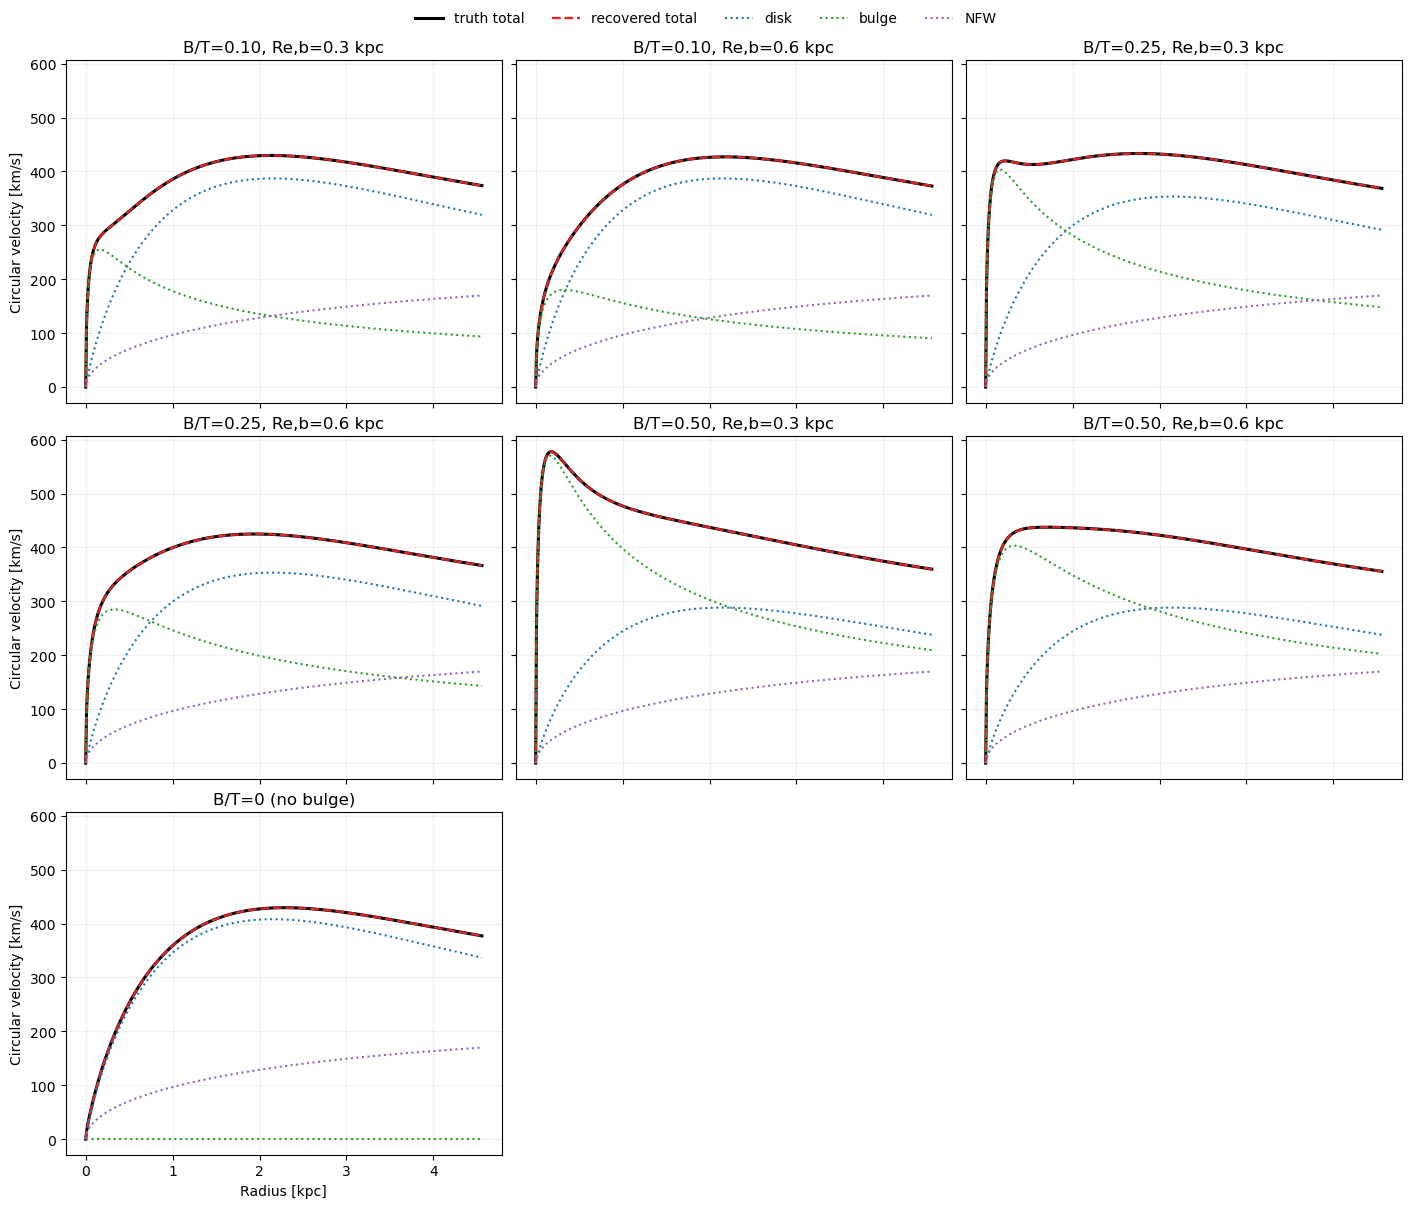

In [7]:
ncols = 3
nrows = int(np.ceil(len(CASES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True, squeeze=False, constrained_layout=True)
for ax, case in zip(axes.flat, CASES):
    result = RESULTS[case['name']]
    truth_curve = rotation_curve(case)
    best_curve = rotation_curve(result['best_parameters'])
    ax.plot(RADIUS_KPC, truth_curve['total_kms'], color='black', lw=2.2, label='truth total')
    ax.plot(RADIUS_KPC, best_curve['total_kms'], color='tab:red', lw=1.7, ls='--', label='recovered total')
    ax.plot(RADIUS_KPC, truth_curve['disk_kms'], color='tab:blue', ls=':', label='disk')
    ax.plot(RADIUS_KPC, truth_curve['bulge_kms'], color='tab:green', ls=':', label='bulge')
    ax.plot(RADIUS_KPC, truth_curve['halo_kms'], color='tab:purple', ls=':', label='NFW')
    title = 'B/T=0 (no bulge)' if case['bulge_to_total'] == 0 else f"B/T={case['bulge_to_total']:.2f}, Re,b={case['bulge_effective_radius_kpc']:.1f} kpc"
    ax.set_title(title)
    ax.grid(alpha=0.2)
for ax in axes.flat[len(CASES):]: ax.set_visible(False)
for ax in axes[:, 0]: ax.set_ylabel('Circular velocity [km/s]')
for ax in axes[-1]: ax.set_xlabel('Radius [kpc]')
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper center', ncol=5, frameon=False)
plt.show()

## Cube residuals and local identifiability

The left panels show truth moment 0 and the right panels show recovered minus truth. The Jacobian condition number diagnoses locally weak parameter combinations.

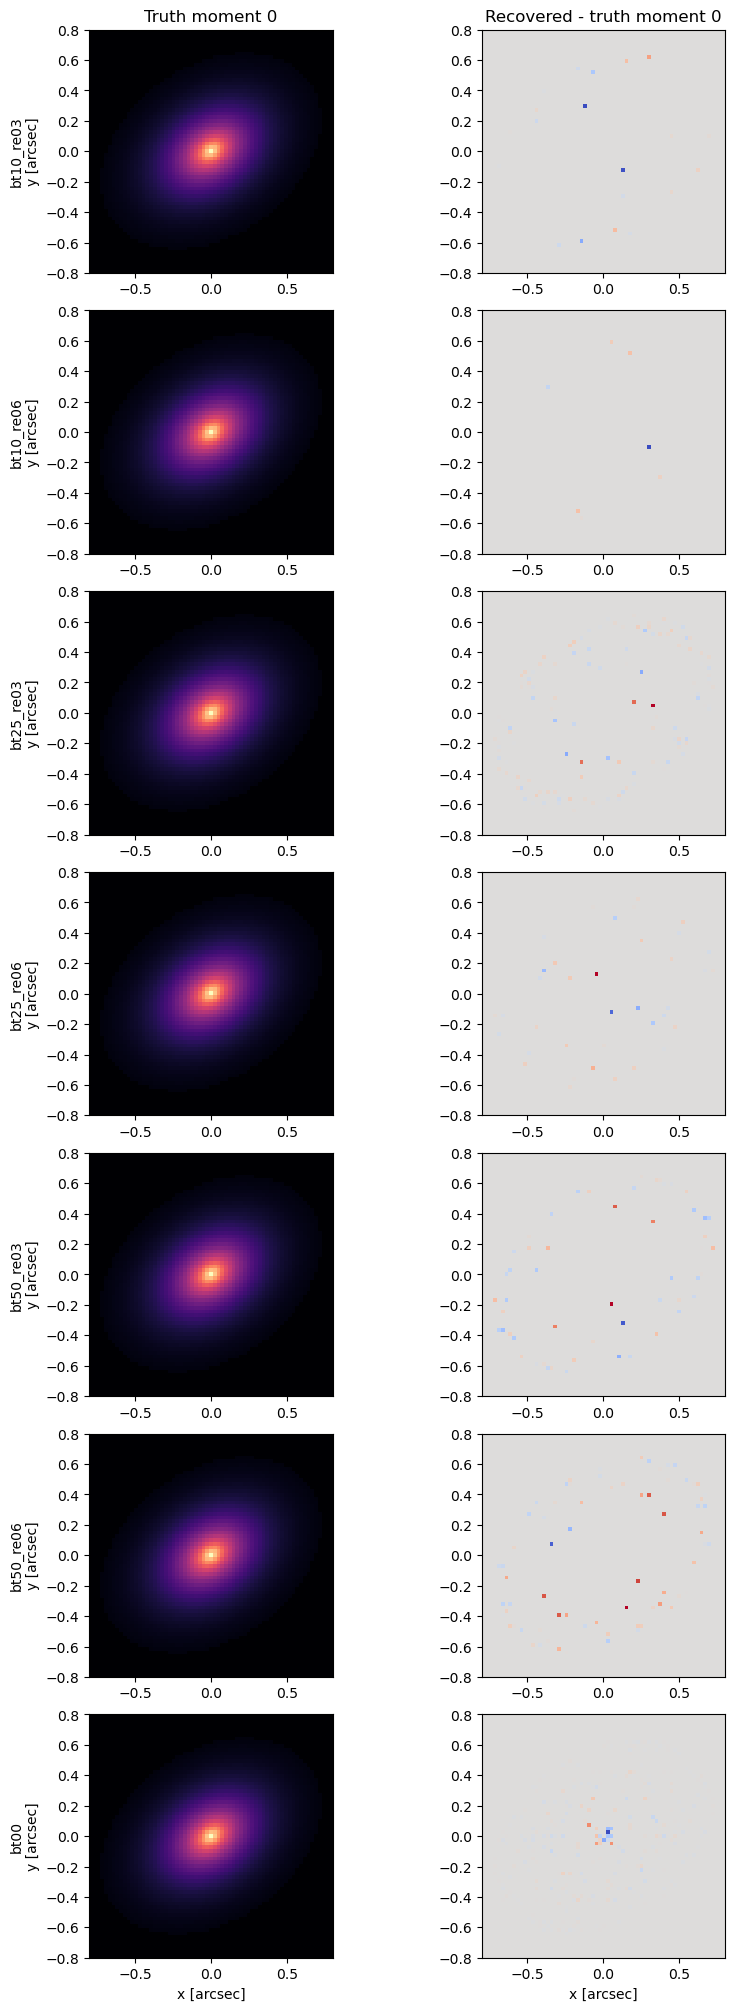

case,Jacobian condition number,smallest singular value
str9,float64,float64
bt10_re03,385.45931085515286,0.16130477206862645
bt10_re06,352.6613236605837,0.14434648439688777
bt25_re03,379.6248553002865,0.16270909175355971
bt25_re06,353.7758345325739,0.1463955695058807
bt50_re03,392.4514758525596,0.17513208375031597
bt50_re06,352.94696405955233,0.15412470216827784
bt00,inf,0.0


In [8]:
fig, axes = plt.subplots(len(CASES), 2, figsize=(8, 20), constrained_layout=True)
diagnostics = []
extent = [XX_ARCSEC.min(), XX_ARCSEC.max(), YY_ARCSEC.min(), YY_ARCSEC.max()]
for row, case in enumerate(CASES):
    result = RESULTS[case['name']]
    moment0 = result['data_cube'].sum(axis=0)
    residual0 = (result['best_cube'] - result['data_cube']).sum(axis=0)
    axes[row, 0].imshow(moment0, origin='lower', extent=extent, cmap='magma')
    limit = max(float(np.max(np.abs(residual0))), 1e-12)
    axes[row, 1].imshow(residual0, origin='lower', extent=extent, cmap='coolwarm', vmin=-limit, vmax=limit)
    axes[row, 0].set_ylabel(case['name'] + '\ny [arcsec]')
    singular = result['jacobian_singular_values']
    condition_number = np.inf if singular[-1] == 0.0 else singular[0] / singular[-1]
    diagnostics.append((case['name'], condition_number, singular[-1]))
axes[0, 0].set_title('Truth moment 0')
axes[0, 1].set_title('Recovered - truth moment 0')
for ax in axes[-1]: ax.set_xlabel('x [arcsec]')
plt.show()
Table(rows=diagnostics, names=('case', 'Jacobian condition number', 'smallest singular value'))

## Interpretation

Passing this test establishes that the intrinsic cube implementation can recover its own mass parameters under ideal conditions. In the B/T=0 case, the bulge effective radius is physically undefined and therefore cannot be recovered; its configured value is only a positive placeholder for the common forward-model signature. It does **not** establish that real observations can constrain every free parameter. Subsequent stages add lensing, PSF convolution, and noise one at a time.